In [6]:
import json

# labels.txt to labels.json
with open('./labels.txt', 'r') as f:
    lines = f.readlines()
    
labelsdict = {}

for i, line in enumerate(lines):
    # Agate (玛瑙)\n -> Agate
    lines[i] = line.split()[0]
    labelsdict[str(i)] = lines[i]

mineral_dict = labelsdict

labelsdict = json.dumps(labelsdict, indent=4)
with open('./labels.json', 'w') as f:
    f.write(labelsdict)

In [7]:
import os

minerals_path = './data'

dirlist = os.listdir(minerals_path)

samples = []
labelNum = [0] * 36

for dir in dirlist:

    dirpath = os.path.join(minerals_path, dir)

    img_names = os.listdir(dirpath)

    for img_name in img_names:
        f_name = os.path.join(dirpath, img_name)
        multi_labels = img_name.split('.')[0].split('_')[1:]
        categories = [mineral_dict[i] for i in multi_labels]

        for label in multi_labels:
            labelNum[int(label)] += 1

        sample = {
            'fname': f_name,
            'labels': multi_labels,
            'categories': categories
        }
        samples.append(sample)

In [8]:
import random

random.shuffle(samples)

n = len(samples)

train_samples = samples[:int(n * 0.9)]
valid_samples = samples[int(n * 0.9): int(n * 0.95)]
test_samples = samples[int(n * 0.95):]

def sampls_2_json(samples, path):
    random.shuffle(samples)
    samples = json.dumps(samples, indent=4)
    with open(path, 'w') as f:
        f.write(samples)

dir = './annotations'
if not os.path.exists(dir):
    os.makedirs(dir)

sampls_2_json(train_samples, './annotations/train.json')
sampls_2_json(valid_samples, './annotations/valid.json')
sampls_2_json(test_samples, './annotations/test.json')

[('Quartz', 55059), ('Fluorite', 28290), ('Pyrite', 12224), ('Malachite', 10256), ('Sphalerite', 9796), ('Beryl', 9282), ('Azurite', 8733), ('Galena', 8513), ('Hematite', 8012), ('Wulfenite', 7711), ('Elbaite', 5699), ('Copper', 5460), ('Chalcopyrite', 5408), ('Albite', 5101), ('Gold', 4600), ('Rhodochrosite', 4550), ('Epidote', 4427), ('Topaz', 3758), ('Opal', 3532), ('Agate', 3357), ('Cassiterite', 3343), ('Schorl', 3262), ('Magnetite', 2765), ('Stibnite', 2637), ('Marcasite', 2144), ('Almandine', 2072), ('Sulphur', 1958), ('Anglesite', 1926), ('Diopside', 1718), ('Cinnabar', 1655), ('Torbernite', 1124), ('Sapphire', 1010), ('Ruby', 828), ('Halite', 763), ('Demantoid', 755), ('Orpiment', 740)]


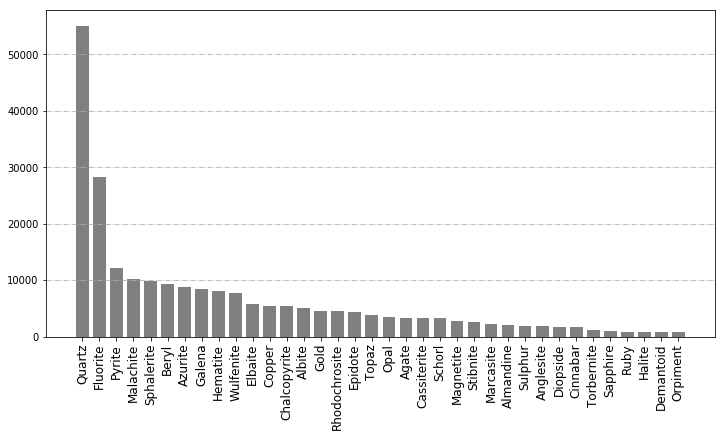

In [8]:
labelNum_Dict = {}
for i in range(len(labelNum)):
    labelNum_Dict[mineral_dict[str(i)]] = labelNum[i]

labelNum_tuple = sorted(labelNum_Dict.items(), key=lambda item: item[1], reverse=True)
print(labelNum_tuple)